<a href="https://colab.research.google.com/github/Saddeee/kex/blob/main/KEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# !pip install -q tqdm keras tensorflow   # Uncomment on a fresh Colab runtime
import io, random, zipfile
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from time import time
from typing import Dict, List, Tuple
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import tensorflow as tf
from tqdm import tqdm

import keras
from keras.layers import Concatenate, Dense, Embedding, Flatten, Input, Multiply
from keras.models import Model
from keras.optimizers import SGD
from keras.regularizers import l2

gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} | GPUs: {gpus}")

TensorFlow 2.19.0 | GPUs: []


In [18]:
# ── Cell 1: Data Loading ──────────────────────────────────────────────────────
def load_data() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    zf = zipfile.ZipFile(io.BytesIO(response.content))

    def read_dat(name: str, cols: List[str], split) -> pd.DataFrame:
        raw = zf.read(f"ml-100k/{name}").decode("latin-1")
        return pd.read_csv(io.StringIO(raw), sep=split, engine="python", names=cols)

    users   = read_dat("u.user",   ["UserID", "Gender", "Age", "Occupation", "Zip-code"], "|")
    movies  = read_dat("u.item",  ["MovieID", "Title", "Genres"], "|")
    ratings = read_dat("u.data", ["UserID", "MovieID", "Rating", "Timestamp"], "\t")
    print(f"Loaded: {len(users)} users | {len(movies)} movies | {len(ratings)} ratings")
    return users, movies, ratings

users_df, movies_df, ratings_df = load_data()
display(users_df.head(3))
display(movies_df.head(3))
display(ratings_df.head(3))


movies =  movies_df["MovieID"].to_numpy()


Loaded: 943 users | 1682 movies | 100000 ratings


,UserID,Gender,Age,Occupation,Zip-code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067


,,,,,,,,,,,,,,,,,,,,,MovieID,Title,Genres
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%20(1995),0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(1995),0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


,UserID,MovieID,Rating,Timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116


In [19]:
# Rating class
class Rating:

    def __init__(self, user_id, movie_id, rating, timestamp):

        self.user_id = user_id
        self.movie_id = movie_id
        self.rating = rating
        self.timestamp = timestamp

    def __str__(self):

        return f"{self.user_id}, {self.movie_id}, {self.rating}, {self.timestamp}"
    # Required so Rating objects can live in sets (used during negative sampling)
    def __hash__(self):
        return hash((self.user_id, self.movie_id))

    def __eq__(self, other):
        return (self.user_id, self.movie_id) == (other.user_id, other.movie_id)

def _to_user_rating_dict(ratings_input) -> Dict[int, List[Rating]]:
    if isinstance(ratings_input, np.ndarray):
        d = defaultdict(list)
        for row in ratings_input:
            uid, mid, r, ts = int(row[0]), int(row[1]), float(row[2]), int(row[3])
            d[uid].append(Rating(uid, mid, r, ts))
        return d
    elif isinstance(ratings_input, dict):
        return {u: list(rs) for u, rs in ratings_input.items()}  # shallow copy
    else:
        raise TypeError(f"Unsupported input type: {type(ratings_input)}")

# -----------------------------
# Leave-One-Out Split
# -----------------------------
def leave_one_out_split(ratings_input):
    user_to_rating = _to_user_rating_dict(ratings_input)
    train: Dict[int, List[Rating]] = {}
    test:  Dict[int, Rating]       = {}
    for user, values in user_to_rating.items():
        if len(values) < 2:
            continue
        values.sort(key=lambda r: r.timestamp)
        test[user]  = values[-1]
        train[user] = values[:-1]
    return train, test

NUM_NEGATVIES = 4
# -----------------------------
# Negative Sampling (implicit training only)
# -----------------------------
def add_negative_samples(train_dict, num_movies, num_neg = NUM_NEGATVIES):
    implicit_train = {}
    all_movies_set = set(range(1, num_movies + 1))
    for user, values in train_dict.items():
        rated_movies = {r.movie_id for r in values}
        positives    = [Rating(r.user_id, r.movie_id, 1, r.timestamp) for r in values]
        negatives: List[Rating] = []
        unrated_movies = list(all_movies_set - rated_movies)
        num_neg_to_sample = len(positives)


        num_neg_to_sample = min(len(unrated_movies)*num_neg, num_neg_to_sample)

        sampled_movie_ids = random.sample(unrated_movies, num_neg_to_sample)
        negatives = [Rating(user, m_id, 0, -1) for m_id in sampled_movie_ids]

        """
        while len(negatives) < len(values):
            sample = np.random.randint(1, num_movies + 1)
            if sample not in rated_movies:
                rated_movies.add(sample)   #added remvoe duplicate negatives ith random
                negatives.append(Rating(user, sample, 0, -1))
                """
        implicit_train[user] = positives + negatives
    return implicit_train

In [20]:
# Cell3 --------------Dataset Preparation-----------
NUM_USERS_SUBSET = 100   # increase for more coverage

first_users  = ratings_df["UserID"].unique()[:NUM_USERS_SUBSET]
subset_numpy = ratings_df[ratings_df["UserID"].isin(first_users)].to_numpy()

# Three-way split via nested leave-one-out
tmp_train, test_set       = leave_one_out_split(subset_numpy)
training_split, valid_set = leave_one_out_split(tmp_train)

num_movies = int(ratings_df.MovieID.max())
max_user_id  = int(ratings_df.UserID.max())

num_users = max_user_id + 1
num_items = num_movies + 1


implicit_training_split = add_negative_samples(training_split, num_movies)

test_set_implicit  = copy.deepcopy(test_set)
valid_set_implicit = copy.deepcopy(valid_set)
for r in test_set_implicit.values():  r.rating = 1
for r in valid_set_implicit.values(): r.rating = 1


print(f"Train users : {len(training_split)}")
print(f"Val users   : {len(valid_set)}")
print(f"Test users  : {len(test_set)}")
print(f"Explicit train ratings : {sum(len(v) for v in training_split.values())}")
print(f"Implicit train ratings : {sum(len(v) for v in implicit_training_split.values())}")


Train users : 100
Val users   : 100
Test users  : 100
Explicit train ratings : 17508
Implicit train ratings : 35016


In [21]:
#---Cell 4: Matrix Factorisation (SVD)---- NOtera att MF = SVD, ska gör det tydligare sen

def calculate_global_mean(train_data):
    total, count = 0.0, 0
    for values in train_data.values():
        for r in values:
            total += r.rating
            count += 1
    return total / count if count > 0 else 0.0


def predict(u, i, b_users, b_items, p_users, q_items, global_mean):
  return global_mean + b_users[u] + b_items[i] + float(np.dot(p_users[u], q_items[i]))



def init_mf_params(num_users: int, num_items: int, k: int):
    b_users = np.zeros(num_users + 1)
    b_items = np.zeros(num_items + 1)
    p_users = np.random.normal(0, 0.1, (num_users + 1, k))
    q_items = np.random.normal(0, 0.1, (num_items + 1, k))
    return b_users, b_items, p_users, q_items


# -----------------------------
# Training
# -----------------------------
def train(train_data, b_users, b_items, p_users, q_items, global_mean, epochs=10, lr=0.01, reg=0.02, batch_size=1024):
    samples = [(r.user_id, r.movie_id, r.rating) for values in train_data.values() for r in values]
    n = len(samples)
    samples = np.array(samples)
    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)


        loss = 0.0

        for i in range(0, n, batch_size):
          batch_idx = indices[i : i + batch_size]
          u = samples[batch_idx, 0].astype(int)
          i_feat = samples[batch_idx, 1].astype(int)
          r = samples[batch_idx, 2]
          dots = np.sum(p_users[u] * q_items[i_feat], axis=1)
          preds = global_mean + b_users[u] + b_items[i_feat] + dots
          errs = r - preds
          loss += np.sum(errs**2)

          np.add.at(b_users, u, lr * (errs - reg * b_users[u]))
          np.add.at(b_items, i_feat, lr * (errs - reg * b_items[i_feat]))

          #shape the error to (err,1) so that we can use it on the p and q vectors
          errs_reshaped = errs[:, np.newaxis]
          p_update = lr * (errs_reshaped * q_items[i_feat] - reg * p_users[u])
          q_update = lr * (errs_reshaped * p_users[u] - reg * q_items[i_feat])

          np.add.at(p_users, u, p_update)
          np.add.at(q_items, i_feat, q_update)
        yield epoch, loss / n
#hyperparameter tuning
"""
def hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    # Change logic to "Higher is Better" for NDCG
    best_ndcg = -np.inf


    best_params = {}
    results = {}
    best_eval_for_k = {}

    for k in K_values:
        b_items = np.zeros(num_items+1)
        q_items = np.random.normal(0, 0.1, (num_items+1, k))
        b_users = np.zeros(num_users+1)
        p_users = np.random.normal(0, 0.1, (num_users+1, k))

        current_k_losses = []

        best_local = -np.inf

        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items)):
            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag)
            current_k_losses.append(loss)
            if current_ndcg > best_local:
                best_local = current_ndcg
                best_eval_for_k[k] = current_ndcg

            # Update best parameters if NDCG improved
            if current_ndcg > best_ndcg:
                best_ndcg = current_ndcg
                best_k = k
                # Capture the state of the best model
                best_params = {
                    'b_items': b_items.copy(),
                    'q_items': q_items.copy(),
                    'b_users': b_users.copy(),
                    'p_users': p_users.copy()
                }


        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return best_params['b_items'], best_params['q_items'], best_params['b_users'], best_params['p_users'], results, best_eval_for_k

def hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    best_ndcg = -np.inf

    best_params = {}
    results = {}
    best_eval_for_k = {}

    #  Calculate global mean once
    global_mean = calculate_global_mean(training_split)

    for k in K_values:
        b_items = np.zeros(num_items+1)
        q_items = np.random.normal(0, 0.1, (num_items+1, k))
        b_users = np.zeros(num_users+1)
        p_users = np.random.normal(0, 0.1, (num_users+1, k))

        current_k_losses = []
        best_local = -np.inf


        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items, global_mean)):

            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag, global_mean=global_mean)

            current_k_losses.append(loss)
            if current_ndcg > best_local:
                best_local = current_ndcg
                best_eval_for_k[k] = current_ndcg

            # Update best parameters if NDCG improved
            if current_ndcg > best_ndcg:
                best_ndcg = current_ndcg
                best_k = k
                best_params = {
                    'b_items': b_items.copy(),
                    'q_items': q_items.copy(),
                    'b_users': b_users.copy(),
                    'p_users': p_users.copy()
                }

        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return best_params['b_items'], best_params['q_items'], best_params['b_users'], best_params['p_users'], results, best_eval_for_k





def hyperparameter_tuning_ncf(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    best_ndcg = -np.inf

    best_params = {}
    best_model = None
    results = {}
    best_eval_for_k = {}

    #  Calculate global mean once
    global_mean = calculate_global_mean(training_split)

    for k in K_values:



        for i in range(10):

          ## model
          model = get_model_GMF(num_users, num_items, k)

          current_k_losses = []
          best_local = -np.inf


          #for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items, global_mean)):

          ##for i in range(0, epoch):

          model = train_GMF(training_split, num_items)

          #current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag, global_mean=global_mean)
          current_ndcg = evaluate_implicit_ndcg_GMF(training_split, validation_set, num_items, model)

          current_k_losses.append(loss)
          if current_ndcg > best_local:
              best_local = current_ndcg
              best_eval_for_k[k] = current_ndcg

          # Update best parameters if NDCG improved
          if current_ndcg > best_ndcg:
              best_ndcg = current_ndcg
              best_k = k
              best_model = model


        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return model, results, best_eval_for_k



"""

'\ndef hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items):\n    K_values = [8, 16, 32, 64]\n    best_k = 0\n    # Change logic to "Higher is Better" for NDCG\n    best_ndcg = -np.inf\n\n\n    best_params = {}\n    results = {}\n    best_eval_for_k = {}\n\n    for k in K_values:\n        b_items = np.zeros(num_items+1)\n        q_items = np.random.normal(0, 0.1, (num_items+1, k))\n        b_users = np.zeros(num_users+1)\n        p_users = np.random.normal(0, 0.1, (num_users+1, k))\n\n        current_k_losses = []\n\n        best_local = -np.inf\n\n        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items)):\n            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag)\n            current_k_losses.append(loss)\n            if current_ndcg > best_local:\n                best_local = current_ndcg\n                best_eval_for_k[k] = current_ndcg\n\n 

In [22]:
# ── Cell 5: Neural Collaborative Filtering Models ────── uppdatera med ta bort args classerna innan som hade en per train_*
@dataclass
class NCFConfig:
    num_factors: int        = 8
    num_neg:     int        = NUM_NEGATVIES
    lr:          float      = 0.01
    epochs:      int        = 10
    batch_size:  int        = 512
    mf_dim:      int        = 8
    layers:      List[int]  = field(default_factory=lambda: [64, 32, 16])
    reg_layers:  List[float]= field(default_factory=lambda: [0.0, 0.0, 0.0])
    reg_mf:      float      = 0.0

def get_model_GMF(num_users, num_items, latent_dim, regs=[0,0]):
    # Input variables
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')


    MF_Embedding_User = Embedding(input_dim = num_users, output_dim = latent_dim, name = 'user_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(regs[0]), input_length=1) # Changed: init, W_regularizer
    MF_Embedding_Item = Embedding(input_dim = num_items, output_dim = latent_dim, name = 'item_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(regs[1]), input_length=1) # Changed: init, W_regularizer

    # Crucial to flatten an embedding vector!
    user_latent = Flatten()(MF_Embedding_User(user_input))
    item_latent = Flatten()(MF_Embedding_Item(item_input))

    # Element-wise product of user and item embeddings
    predict_vector = Multiply()([user_latent, item_latent]) # siwthc merge -> Mulitply

    # Final prediction layer
    #prediction = Lambda(lambda x: K.sigmoid(K.sum(x)), output_shape=(1,))(predict_vector)
    prediction = Dense(1, activation='sigmoid', kernel_initializer='lecun_uniform', name = 'prediction')(predict_vector) # Changed: init to kernel_initializer

    model = Model(inputs=[user_input, item_input], outputs=prediction) # Changed: input to inputs, output to outputs

    return model

def get_model_MLP(num_users, num_items, layers=[20, 10], reg_layers=[0,0]):
    assert len(layers) == len(reg_layers)
    # Input variables
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')
    num_layers = len(layers)

    MLP_Embedding_User = Embedding(input_dim = num_users, output_dim = layers[0]//2, name = 'user_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer
    MLP_Embedding_Item = Embedding(input_dim = num_items, output_dim = layers[0]//2, name = 'item_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer

    # Crucial to flatten an embedding vector!
    user_latent = Flatten()(MLP_Embedding_User(user_input))
    item_latent = Flatten()(MLP_Embedding_Item(item_input))

    # The 0-th layer is the concatenation of embedding layers
    vector = Concatenate()([user_latent, item_latent])

    # MLP layers old version
    for idx in range(1, num_layers):
        layer = Dense(layers[idx], kernel_regularizer= l2(reg_layers[idx]), activation='relu', name = 'layer%d' %idx)
        vector = layer(vector)
    #suggested
    """"
    for idx, (units, reg) in enumerate(zip(layers[1:], reg_layers[1:]), start=1):
        vector = Dense(units, activation="relu",
                       kernel_regularizer=l2(reg), name=f"layer{idx}")(vector)
    """
    # single prediction layer (orgi had two)
    prediction = Dense(1, activation="sigmoid",kernel_initializer="lecun_uniform",name="prediction")(vector)
    model = Model(inputs=[user_input, item_input], outputs=prediction)

    return model
def get_model_NeuMF(num_users, num_items, mf_dim=10, layers=[10], reg_layers=[0], reg_mf=0):
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')
    num_layers = len(layers) #Number of layers in the MLP


    MF_Embedding_User = Embedding(input_dim = num_users, output_dim = mf_dim, name = 'MF_user_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(reg_mf), input_length=1) # Changed: init, W_regularizer
    MF_Embedding_Item = Embedding(input_dim = num_items, output_dim = mf_dim, name = 'MF_item_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(reg_mf), input_length=1) # Changed: init, W_regularizer

    MLP_Embedding_User = Embedding(input_dim = num_users, output_dim = layers[0]//2, name = 'MLP_user_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer
    MLP_Embedding_Item = Embedding(input_dim = num_items, output_dim = layers[0]//2, name = 'MLP_item_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer

    # Crucial to flatten an embedding vector! MLP
    mlp_user_latent = Flatten()(MLP_Embedding_User(user_input))
    mlp_item_latent = Flatten()(MLP_Embedding_Item(item_input))
    # Crucial to flatten an embedding vector! MF
    mf_user_latent = Flatten()(MF_Embedding_User(user_input))
    mf_item_latent = Flatten()(MF_Embedding_Item(item_input))
    mf_vector = Multiply()([mf_user_latent, mf_item_latent]) # siwthc merge -> Mulitply


    # The 0-th layer is the concatenation of embedding layers
    mlp_vector = Concatenate()([mlp_user_latent, mlp_item_latent])
    for idx in range(1, num_layers):
        layer = Dense(layers[idx], kernel_regularizer= l2(reg_layers[idx]), activation='relu', name = 'layer%d' %idx)
        mlp_vector = layer(mlp_vector)




    # Final prediction layer
    prediction_vector = Concatenate()([mf_vector,mlp_vector]) # siwthc merge -> Mulitply

    prediction = Dense(1, activation='sigmoid', kernel_initializer='lecun_uniform',name='prediction')(prediction_vector)

    return Model(inputs=[user_input, item_input], outputs=prediction)


"""
def init_normal(shape, name=None):
    return initializers.normal(shape, stddev=0.01, name=name) # Changed: scale to stddev
"""

'\ndef init_normal(shape, name=None):\n    return initializers.normal(shape, stddev=0.01, name=name) # Changed: scale to stddev\n'

In [23]:
#Cell 6 keras shared training

def keras_train_instaces(train_dict, num_items, num_negatives =8):
  user_input, item_input, labels = [],[],[]
  for user, ratings in train_dict.items():
    postive_items = {r.movie_id for r in ratings}
    for r in ratings:
      user_input.append(user)
      item_input.append(r.movie_id)
      labels.append(1)
      #handle negative
      for _ in range(num_negatives):
        j = np.random.randint(1, num_items)
        while j in postive_items:
          j = np.random.randint(1, num_items)
        user_input.append(user)
        item_input.append(j)
        labels.append(0)
  return np.array(user_input), np.array(item_input), np.array(labels)

def train_keras_model(model,train_dict,num_items, cfg):
    #  three near-identical train_GMF / train_MLP / train_NeuMF -> one
    # only the model architecture differed, which is handled by get_model_*.

    #tf.data pipeline with prefetch(AUTOTUNE) ensures the CPU-side
    # negative sampling never starves the GPU.
    #
    # variable loss, hist.history['loss'][0] is used here instead.
    model.compile(optimizer=SGD(learning_rate=cfg.lr), loss="binary_crossentropy")
    loss_history: List[float] = []
    for epoch in range(cfg.epochs):
        t0 = time()
        user_arr, item_arr, label_arr = keras_train_instaces(train_dict, num_items, cfg.num_neg)
        dataset = (
            tf.data.Dataset
            .from_tensor_slices(((user_arr, item_arr), label_arr)) #wrap np arr as sample
            .shuffle(buffer_size=len(label_arr)) #ranodm within epoch
            .batch(cfg.batch_size)
            .prefetch(tf.data.AUTOTUNE)   # overlap CPU prep with GPU training
      )
        hist       = model.fit(dataset, epochs=1, verbose=0) #model fit returns historu object
        epoch_loss = hist.history["loss"][0]   # defined — no NameError
        loss_history.append(epoch_loss)
        print(f"  Epoch {epoch+1}/{cfg.epochs} | loss={epoch_loss:.4f} [{time()-t0:.1f}s]")
    return model, loss_history



In [24]:
# Cell 7 Evaluation Functions

#make all metric function accept function score_fun

#share sampling used by MF and Neural stuff
"""
#   Svd:     score_fn = make_mf_scorer(b_users, b_items, p_users, q_items, gm)
#   Neu: score_fn = make_neural_scorer(model, batch_size=512)
"""

def make_mf_scorer(b_users, b_items, p_users, q_items, global_mean):
    def score_fn(user_ids: np.ndarray, movie_ids: np.ndarray) -> np.ndarray:
        return np.array([
            predict(u, m, b_users, b_items, p_users, q_items, global_mean) for u, m in zip(user_ids, movie_ids)
        ])
    return score_fn


def make_neural_scorer(model: Model, batch_size: int = 512):
    def score_fn(user_ids: np.ndarray, movie_ids: np.ndarray) -> np.ndarray:
        users_t  = tf.constant(user_ids,  dtype=tf.int32)
        movies_t = tf.constant(movie_ids, dtype=tf.int32)
        chunks   = []
        for start in range(0, len(user_ids), batch_size):
            preds = model(
                [users_t[start:start + batch_size],
                 movies_t[start:start + batch_size]],
                training=False,
            )
            chunks.append(preds)
        return tf.concat(chunks, axis=0).numpy().flatten()
    return score_fn

def _sample_candidates(true_movie, rated_movies, num_movies, n_neg):
    negatives = set()
    while len(negatives) < n_neg:
        movie = np.random.randint(1, num_movies)
        if movie not in rated_movies and movie != true_movie:
            negatives.add(movie)
    return list(negatives) + [true_movie]

# -----------------------------
# RMSE
# -----------------------------
def rmse(test, b_users, b_items, p_users, q_items, global_mean):
    errors = []
    for user, r in tqdm(test.items(), desc="RMSE", unit="user"):
        pred = predict(user, r.movie_id, b_users, b_items, p_users, q_items, global_mean)
        errors.append((r.rating - pred)**2)
    return np.sqrt(np.mean(errors))

#general verison of rmse
def compute_rmse(test, score_fn):
    user_arr  = np.array([u           for u in test.keys()],   dtype=np.int32)
    movie_arr = np.array([r.movie_id  for r in test.values()], dtype=np.int32)
    true_arr  = np.array([r.rating    for r in test.values()], dtype=np.float32)
    pred_arr  = score_fn(user_arr, movie_arr)
    return float(np.sqrt(np.mean((true_arr - pred_arr) ** 2)))


#general ndcgg
def compute_ndcg(train, test, num_movies, score_fn, mode="implicit", K=10, n_neg=10):
    all_users, all_movies, user_order = [], [], []
    for user, r in test.items():
        rated = {x.movie_id for x in train.get(user, [])}
        candidates = _sample_candidates(r.movie_id, rated, num_movies, n_neg)
        all_users.extend([user] * len(candidates))
        all_movies.extend(candidates)
        user_order.append((user, r.movie_id, r.rating, len(candidates)))

    all_scores = score_fn(np.array(all_users, dtype=np.int32), np.array(all_movies, dtype=np.int32))

    user_scores = [] # Track individual scores to calculate CI
    idx = 0
    for user, true_movie, true_rating, n_cands in user_order:
        scores_u = all_scores[idx : idx + n_cands]
        candidates_u = all_movies[idx : idx + n_cands]
        idx += n_cands

        ranking = np.argsort(scores_u)[::-1]
        pos_index = list(candidates_u).index(true_movie)
        rank = int(np.where(ranking == pos_index)[0][0])

        score = 0.0
        if rank < K:
            rel = 1.0 if mode == "implicit" else true_rating
            dcg = (2 ** rel - 1) / np.log2(rank + 2)
            idcg = (2 ** rel - 1) / np.log2(2)
            score = (dcg / idcg) if idcg > 0 else 0.0
        user_scores.append(score)

    mean_ndcg = np.mean(user_scores)
    # 95% konfidence intervall:  1.96 * (StdDev / sqrt(N))
    ci_margin = 1.96 * (np.std(user_scores) / np.sqrt(len(user_scores)))

    return mean_ndcg, ci_margin


# ── MF NDCG explicit and implicit unified
def evaluate_mf_ndcg(train, test, num_movies,b_users, b_items, p_users, q_items, global_mean,mode="implicit",  K=10, verbose=True):
    # evaluate_implicit_ndcg + evaluate_explicit_ndcg merged
    # same candidate sampling, same scoring, same ranking differed (1 vs r.rating).
    # i is the enumerate index inte movieid.
    user_scores = []
    for user, r in tqdm(test.items(), desc=f"NDCG [{mode}]", unit="user", disable=not verbose):
        rated = {x.movie_id for x in train[user]}
        # notera k used as # of negative samples
        candidates = _sample_candidates(r.movie_id, rated, num_movies, K)
        scores = np.array([predict(user, movie, b_users, b_items, p_users, q_items, global_mean) for movie in candidates])
        ranking = np.argsort(scores)[::-1]
        pos_index = candidates.index(r.movie_id)
        rank = int(np.where(ranking == pos_index)[0][0])

        score_u = 0.0
        # Only calculate DCG if the item landed in the Top K
        if rank < K:
            rel = 1.0 if mode == "implicit" else r.rating
            dcg = (2 ** rel - 1) / np.log2(rank + 2)
            idcg = (2 ** rel - 1) / np.log2(2)
            score_u = (dcg / idcg) if idcg > 0 else 0.0

        user_scores.append(score_u)

    # Mean y 95% Ci
    mean_ndcg = np.mean(user_scores)
    # Math: 1.96 * (Standard Deviation / Square Root of N)
    ci_margin = 1.96 * (np.std(user_scores) / np.sqrt(len(user_scores)))
    return mean_ndcg, ci_margin

#general hr
def compute_hr(train, test, num_movies, score_fn,K=10, n_neg=100):
    all_users, all_movies, user_order = [], [], []
    for user, r in test.items():
        rated = {x.movie_id for x in train.get(user, [])}
        candidates = _sample_candidates(r.movie_id, rated, num_movies, n_neg)
        all_users.extend([user] * len(candidates))
        all_movies.extend(candidates)
        user_order.append((user, r.movie_id, len(candidates)))

    all_scores = score_fn(np.array(all_users, dtype=np.int32), np.array(all_movies, dtype=np.int32))

    hits = []
    idx = 0
    for user, true_movie, n_cands in user_order:
        scores_u = all_scores[idx : idx + n_cands]
        candidates_u = all_movies[idx : idx + n_cands]
        idx += n_cands
        top_k = [candidates_u[i] for i in np.argsort(scores_u)[::-1][:K]]
        hits.append(1 if true_movie in top_k else 0)

    mean_hr = np.mean(hits)
    ci_margin = 1.96 * (np.std(hits) / np.sqrt(len(hits)))
    return mean_hr, ci_margin

# ── Neural NDCG / HR batched, merged not used
def _batch_predict_neural(all_users, all_movies, model, batch_size=512):
    users_t  = tf.constant(all_users,  dtype=tf.int32)
    movies_t = tf.constant(all_movies, dtype=tf.int32)
    chunks   = []
    for start in range(0, len(all_users), batch_size):
        preds = model([users_t[start:start + batch_size],movies_t[start:start + batch_size]],training=False)
        chunks.append(preds)
    return tf.concat(chunks, axis=0).numpy().flatten()


#not used
def evaluate_neural(train, test, num_movies, model,metric="ndcg",   # "ndcg" | "hr"
    K=10, n_neg=10, batch_size=512, verbose=True):
    # evaluate_implicit_ndcg_GMF + evaluate_implicit_NeuMF_hr -> merged
    # Both built identical candidate lists and ran identical batched predictions;
    # metric (NDCG vs HR@K) differed.

    #här extrend så att alla users alla movies och all users matchar.
    #Om vi tittar på en godtyckligt index i all users så har vi motsvarande film som hen gillar i all movies i. Vi upprepar user i all users så att det matchar all movies
    all_users, all_movies, user_order = [], [], []
    for user, r in tqdm(test.items(), desc="Building eval candidates", unit="user", disable=not verbose):
        rated      = {x.movie_id for x in train[user]}
        candidates = _sample_candidates(r.movie_id, rated, num_movies, n_neg)
        all_users.extend([user] * len(candidates))
        all_movies.extend(candidates)
        user_order.append((user, r.movie_id, len(candidates)))

    all_scores = _batch_predict_neural(all_users, all_movies, model, batch_size)
    total, idx = 0.0, 0
    idcg = 1.0 / np.log2(2)
    for user, true_movie, n_cands in tqdm(user_order, desc=f"Scoring {metric.upper()}@{K}", unit="user", disable=not verbose):
        scores_u   = all_scores[idx : idx + n_cands]
        candidates = all_movies[idx : idx + n_cands]
        idx       += n_cands
        ranking    = np.argsort(scores_u)[::-1]
        top_k      = [candidates[i] for i in ranking[:K]]
        if metric == "hr":
            total += int(true_movie in top_k)
        else:
            pos_index = list(candidates).index(true_movie)
            rank      = int(np.where(ranking == pos_index)[0][0])
            total    += (1.0 / np.log2(rank + 2)) / idcg
    return total / len(test)


In [25]:
# ── Cell 8: Hyperparameter Tuning ─────────────────────────────────────────────
K_VALUES = [8, 16, 32, 64]

#MF parallel across k values
def _tune_single_k_mf(k, training_split, validation_set,num_users, num_items, mode, global_mean, epochs=10):
    b_users, b_items, p_users, q_items = init_mf_params(num_users, num_items, k)
    losses, ndcg_curve, best_ndcg, best_params = [], [], -np.inf, {}
    for epoch, loss in train(training_split, b_users, b_items,p_users, q_items, global_mean, epochs=epochs):
        ndcg, _ = evaluate_mf_ndcg(training_split, validation_set, num_items,b_users, b_items, p_users, q_items,global_mean, mode=mode, verbose=False)
        losses.append(loss)
        ndcg_curve.append(ndcg)
        if ndcg > best_ndcg:
            best_ndcg = ndcg
            best_params = {
                "b_items": b_items.copy(), "q_items": q_items.copy(),
                "b_users": b_users.copy(), "p_users": p_users.copy(),
            }
    return k, losses, ndcg_curve, best_ndcg, best_params

#svd
def hyperparameter_tuning_mf(training_split, validation_set, mode,num_users, num_items, k_values=None, epochs=10):
    # parallel over K using thread pol.
    # (values genuinely overlap on Colab's multi-core CPU.) gpt sa <-
    if k_values is None: k_values = K_VALUES
    global_mean = calculate_global_mean(training_split)
    results, best_eval_for_k           = {}, {}
    best_ndcg, best_k, best_params = -np.inf, None, {}
    all_ndcg_curves = {}
    with ThreadPoolExecutor(max_workers=len(k_values)) as ex:
        futures = {
            ex.submit(_tune_single_k_mf, k, training_split, validation_set,num_users, num_items, mode, global_mean, epochs) : k for k in k_values
        }
        for future in tqdm(as_completed(futures), total=len(k_values),desc=f"Tuning MF [{mode}]"):
            k, losses, ndcg_curve, ndcg, params = future.result()
            results[k]         = losses
            all_ndcg_curves[k] = ndcg_curve
            best_eval_for_k[k] = ndcg
            if ndcg > best_ndcg:
                best_ndcg, best_k, best_params = ndcg, k, params

    print(f"Best K={best_k} | Val NDCG@10={best_ndcg:.4f}")
    return (best_params["b_items"], best_params["q_items"],
            best_params["b_users"], best_params["p_users"],
            results,all_ndcg_curves, best_eval_for_k, global_mean)

def _build_ncf_model(model_type: str, num_users, num_items, k, cfg: NCFConfig) -> Model:
    if   model_type == "GMF":   return get_model_GMF(num_users, num_items, k)
    elif model_type == "MLP":   return get_model_MLP(num_users, num_items,cfg.layers, cfg.reg_layers)
    elif model_type == "NeuMF": return get_model_NeuMF(num_users, num_items,mf_dim=k,layers=cfg.layers,reg_layers=cfg.reg_layers,reg_mf=cfg.reg_mf)
    else: raise ValueError(f"Unknown model_type: {model_type}")

# NCF  kanske lägg in mode s.a vi kan köra olika som neumf, gmf, mlp
def hyperparameter_tuning_ncf(training_split, validation_set, num_users, num_items,model_type="NeuMF", k_values=None, cfg=None):
    if k_values is None: k_values = K_VALUES
    if cfg is None:      cfg = NCFConfig()
    results,all_ndcg_curves, best_eval_for_k           = {}, {},{}
    best_ndcg, best_k, best_model  = -np.inf, None, None

    for k in tqdm(k_values, desc=f"Tuning {model_type}"):
        cfg.mf_dim = k
        model      = _build_ncf_model(model_type, num_users, num_items, k, cfg)
        model.compile(optimizer=SGD(learning_rate=cfg.lr), loss="binary_crossentropy")

        losses:       List[float] = []
        ndcg_curve_k: List[float] = []
        best_local:   float       = -np.inf
        best_weights              = None

        for epoch in range(cfg.epochs):
            t0 = time()
            user_arr, item_arr, label_arr = keras_train_instaces(training_split, num_items, cfg.num_neg)
            dataset = (
                tf.data.Dataset
                .from_tensor_slices(((user_arr, item_arr), label_arr))
                .shuffle(buffer_size=len(label_arr))
                .batch(cfg.batch_size)
                .prefetch(tf.data.AUTOTUNE)
            )
            hist = model.fit(dataset, epochs=1, verbose=0)
            loss = hist.history["loss"][0]
            losses.append(loss)

            # validarte after every eopch and save ndcg. as imporves
            scorer = make_neural_scorer(model)
            ndcg, ndcg_ci   = compute_ndcg(training_split, validation_set,num_items, scorer, mode="implicit")


            ndcg_curve_k.append(ndcg)
            if ndcg > best_local:
                best_local   = ndcg
                best_weights = model.get_weights()

            print(f"  {model_type} K={k} Epoch {epoch+1}/{cfg.epochs} "
                  f"| loss={loss:.4f} | val_NDCG@10={ndcg:.4f} (+/-{ndcg_ci:.4f}) [{time()-t0:.1f}s]")

        results[k]         = losses
        all_ndcg_curves[k]    = ndcg_curve_k
        best_eval_for_k[k] = best_local

        if best_local > best_ndcg:
            best_ndcg  = best_local
            best_k     = k
            best_model = _build_ncf_model(model_type, num_users, num_items, k, cfg)
            best_model.compile(optimizer=SGD(learning_rate=cfg.lr),
                               loss="binary_crossentropy")
            best_model.set_weights(best_weights)

    print(f"Best K={best_k} | Best Val NDCG@10={best_ndcg:.4f}")
    return best_model, results, all_ndcg_curves, best_eval_for_k


In [26]:
# Cell 9: All Experiments
K_VALUES = [8, 16, 32, 64]
EPOCHS   = 3
NCF_CFG  = NCFConfig(epochs=EPOCHS, batch_size=512*2, layers=[64, 32, 16])

all_results: Dict[str, dict] = {}


def run_mf_experiment(name, training_data, validation_data, test_data,mode, num_users, num_items):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    b_items, q_items, b_users, p_users, loss_curves, all_ndcg,eval_k, gm = hyperparameter_tuning_mf(training_data, validation_data, mode,num_users, num_items, k_values=K_VALUES, epochs=EPOCHS)
    scorer    = make_mf_scorer(b_users, b_items, p_users, q_items, gm)
    test_rmse = compute_rmse(test_data, scorer)
    test_ndcg, ndcg_ci = compute_ndcg(training_data, test_data, num_items, scorer, mode=mode)
    test_hr,hr_ci   = compute_hr(training_data, test_data, num_items, scorer)
    best_k    = max(eval_k, key=eval_k.get)
    best_train_curve = all_ndcg[best_k]
    print(f"  RMSE={test_rmse:.4f}  NDCG@10={test_ndcg:.4f}  HR@10={test_hr:.4f}")
    return {
        "loss_curve": loss_curves[best_k],
        "eval_k":     eval_k,
        "best_k":     best_k,
        "RMSE":       test_rmse,
        "NDCG@10":    test_ndcg,
        "HR@10":      test_hr,
        "mode":       mode,
        "ndcg_curve": best_train_curve,
        "HR_CI":      hr_ci,
        "NDCG_CI":     ndcg_ci,
        # Store params for latent-space plot
        "params":     (b_users, b_items, p_users, q_items, gm),
    }


def run_ncf_experiment(name, model_type, training_data, validation_data,
                       test_data, num_users, num_items, num_negatives):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    # Fresh config copy each run so mutations inside tuning don't bleed across
    cfg = NCFConfig(epochs=NCF_CFG.epochs, batch_size=NCF_CFG.batch_size,
                    layers=list(NCF_CFG.layers), reg_layers=list(NCF_CFG.reg_layers), num_neg = num_negatives)
    best_model, loss_curves, train_curve, eval_k = hyperparameter_tuning_ncf(training_data, validation_data, num_users, num_items,model_type=model_type, k_values=K_VALUES, cfg=cfg)
    scorer    = make_neural_scorer(best_model)
    test_rmse = compute_rmse(test_data, scorer)
    test_ndcg, ndcg_ci = compute_ndcg(training_data, test_data, num_items, scorer, mode="implicit")
    test_hr, hr_ci   = compute_hr(training_data, test_data, num_items, scorer)
    best_k    = max(eval_k, key=eval_k.get)
    best_train_curve = train_curve[best_k]
    print(f"  RMSE={test_rmse:.4f}  NDCG@10={test_ndcg:.4f}  HR@10={test_hr:.4f}")
    return {
        "loss_curve": loss_curves[best_k],
        "eval_k":     eval_k,
        "best_k":     best_k,
        "RMSE":       test_rmse,
        "NDCG@10":    test_ndcg,
        "HR@10":      test_hr,
        "mode":       "implicit",
        "ndcg_curve": best_train_curve,
        "model":      best_model,
        "HR_CI":      hr_ci,
        "NDCG_CI":     ndcg_ci,

    }

# ── Experiment 1: Explicit SVD
all_results["MF Explicit"] = run_mf_experiment(
    "Experiment 1: Explicit MF (SVD)",
    training_split, valid_set, test_set,
    mode="explicit", num_users=num_users, num_items=num_items,
)

# ── Experiment 2: Implicit SVD
all_results["MF Implicit"] = run_mf_experiment(
    "Experiment 2: Implicit MF (SVD)",
    implicit_training_split, valid_set_implicit, test_set_implicit,
    mode="implicit", num_users=num_users, num_items=num_items,
)



# ── Experiments 3–5: GMF, MLP, NeuMF Notera att keras_train_instace hanterar redan convertering från postive -> negative samples drf bytte ut implicit mot trianign split
all_results["GMF"] = run_ncf_experiment(
    "Experiment 3: Generalised Matrix Factorisation (GMF)",
    "GMF", training_split, valid_set_implicit, test_set_implicit,num_users=num_users, num_items=num_items, num_negatives = NUM_NEGATVIES)

all_results["MLP"] = run_ncf_experiment(
    "Experiment 4: Multi-Layer Perceptron (MLP)",
    "MLP", training_split, valid_set_implicit, test_set_implicit,
    num_users=num_users, num_items=num_items, num_negatives = NUM_NEGATVIES
)

all_results["NeuMF"] = run_ncf_experiment(
    "Experiment 5: Neural Matrix Factorisation (NeuMF)",
    "NeuMF", training_split, valid_set_implicit, test_set_implicit,
    num_users=num_users, num_items=num_items, num_negatives = NUM_NEGATVIES
)

print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
for name, res in all_results.items():
    line = f"  {name:12s} -> NDCG@10={res['NDCG@10']:.4f}"
    if res["RMSE"]  is not None: line += f"  RMSE={res['RMSE']:.4f}"
    if res["HR@10"] is not None: line += f"  HR@10={res['HR@10']:.4f}"
    print(line)



  Experiment 1: Explicit MF (SVD)


Tuning MF [explicit]: 100%|██████████| 4/4 [00:00<00:00,  4.73it/s]


Best K=64 | Val NDCG@10=0.4987
  RMSE=1.1731  NDCG@10=0.4347  HR@10=0.2000

  Experiment 2: Implicit MF (SVD)


Tuning MF [implicit]: 100%|██████████| 4/4 [00:01<00:00,  3.09it/s]


Best K=16 | Val NDCG@10=0.6618
  RMSE=0.4762  NDCG@10=0.5785  HR@10=0.3200

  Experiment 3: Generalised Matrix Factorisation (GMF)


...

Tuning NeuMF:  75%|███████▌  | 3/4 [00:17<00:05,  5.90s/it]

  NeuMF K=32 Epoch 3/3 | loss=0.5571 | val_NDCG@10=0.4067 (+/-0.0448) [1.2s]
  NeuMF K=64 Epoch 1/3 | loss=0.6555 | val_NDCG@10=0.4059 (+/-0.0462) [2.1s]
  NeuMF K=64 Epoch 2/3 | loss=0.5997 | val_NDCG@10=0.4285 (+/-0.0454) [1.5s]


Tuning NeuMF: 100%|██████████| 4/4 [00:22<00:00,  5.69s/it]

  NeuMF K=64 Epoch 3/3 | loss=0.5635 | val_NDCG@10=0.4087 (+/-0.0495) [1.3s]
Best K=16 | Best Val NDCG@10=0.4697


  RMSE=0.6783  NDCG@10=0.4213  HR@10=0.0900

FINAL RESULTS
  MF Explicit  -> NDCG@10=0.4347  RMSE=1.1731  HR@10=0.2000
  MF Implicit  -> NDCG@10=0.5785  RMSE=0.4762  HR@10=0.3200
  GMF          -> NDCG@10=0.3400  RMSE=0.6397  HR@10=0.0500
  MLP          -> NDCG@10=0.4309  RMSE=0.6410  HR@10=0.1100
  NeuMF        -> NDCG@10=0.4213  RMSE=0.6783  HR@10=0.0900


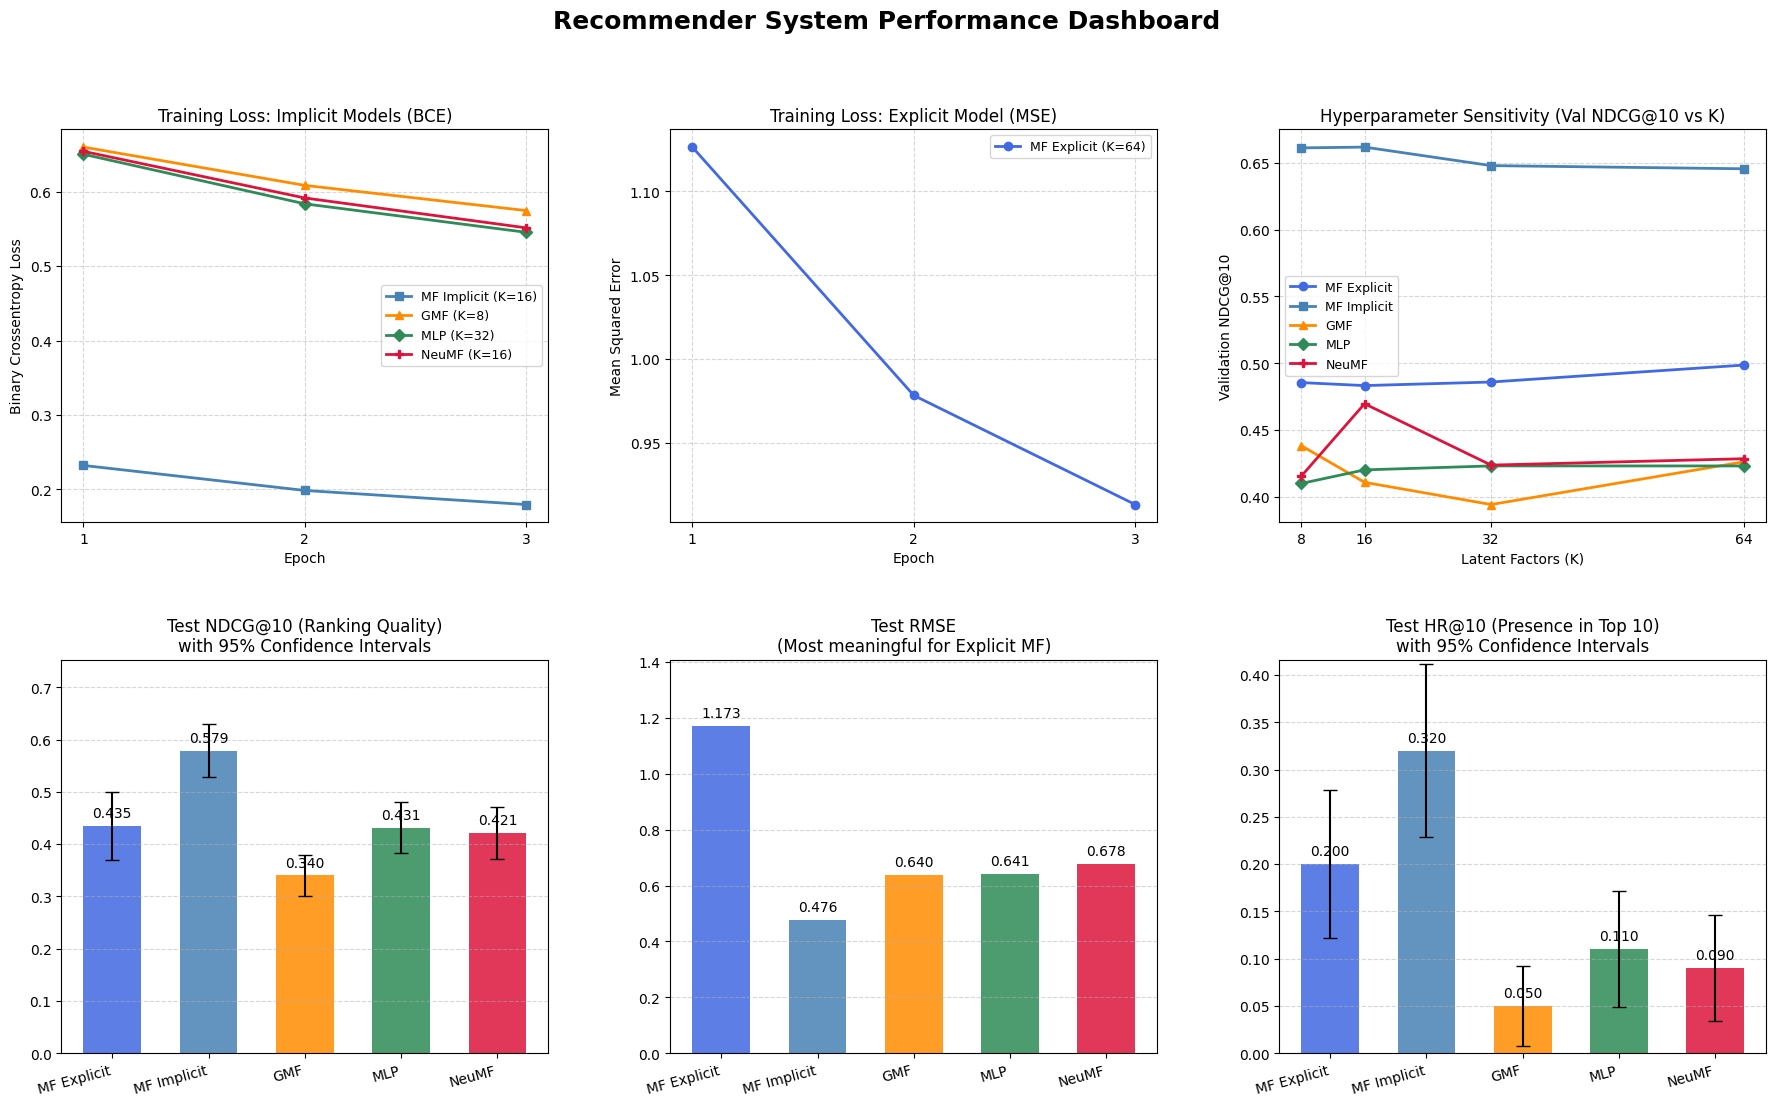

In [27]:

MODEL_COLORS = {
    "MF Explicit": "royalblue",
    "MF Implicit": "steelblue",
    "GMF":         "darkorange",
    "MLP":         "seagreen",
    "NeuMF":       "crimson",
}
MARKERS = {"MF Explicit": "o", "MF Implicit": "s", "GMF": "^", "MLP": "D", "NeuMF": "P"}

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.subplots_adjust(hspace=0.35, wspace=0.25)
fig.suptitle("Recommender System Performance Dashboard", fontsize=18, fontweight="bold")

# ── Plot 1: Implicit Models Training Loss ────────────────────────────────────
ax = axes[0, 0]
for name, res in all_results.items():
    if name != "MF Explicit":
        # Force flatten the array and explicitly define X-coordinates
        y = np.array(res["loss_curve"]).flatten()
        x = np.arange(1, len(y) + 1)
        ax.plot(x, y, label=f"{name} (K={res['best_k']})",
                color=MODEL_COLORS[name], marker=MARKERS[name], linewidth=2)

ax.set_title("Training Loss: Implicit Models (BCE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Crossentropy Loss")
if 'y' in locals(): ax.set_xticks(np.arange(1, len(y) + 1)) # Force integer X-ticks
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

# ── Plot 2: Explicit Model Training Loss ─────────────────────────────────────
ax = axes[0, 1]
if "MF Explicit" in all_results:
    res = all_results["MF Explicit"]
    y = np.array(res["loss_curve"]).flatten()
    x = np.arange(1, len(y) + 1)
    ax.plot(x, y, label=f"MF Explicit (K={res['best_k']})",
            color=MODEL_COLORS["MF Explicit"], marker=MARKERS["MF Explicit"], linewidth=2)
    ax.set_xticks(np.arange(1, len(y) + 1)) # Force integer X-ticks

ax.set_title("Training Loss: Explicit Model (MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

# ── Plot 3: Validation NDCG@10 vs K ──────────────────────────────────────────
ax = axes[0, 2]
for name, res in all_results.items():
    ks = sorted(res["eval_k"].keys())
    y = [res["eval_k"][k] for k in ks]
    ax.plot(ks, y, label=name, color=MODEL_COLORS[name], marker=MARKERS[name], linewidth=2)
ax.set_title("Hyperparameter Sensitivity (Val NDCG@10 vs K)")
ax.set_xlabel("Latent Factors (K)")
ax.set_ylabel("Validation NDCG@10")
ax.set_xticks(K_VALUES)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

# ── Plot 4: Test NDCG@10 with CIs ─────────────────────────────────────────────
ax = axes[1, 0]
names   = list(all_results.keys())
ndcgs   = [all_results[n]["NDCG@10"] for n in names]
ndcg_ci = [all_results[n].get("NDCG_CI", 0) for n in names] # Use .get to avoid errors
colors  = [MODEL_COLORS[n] for n in names]
x_pos   = np.arange(len(names))

# SINGLE bar call with yerr
bars = ax.bar(x_pos, ndcgs, yerr=ndcg_ci, capsize=5, color=colors, alpha=0.85, width=0.6)

ax.set_title("Test NDCG@10 (Ranking Quality)\nwith 95% Confidence Intervals")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, max(ndcgs + [0.1]) * 1.3) # Added padding for error bars
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    ax.annotate(f"{bar.get_height():.3f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=10)

# ── Plot 5: Test RMSE ─────────────────────────────────────────────────────────
ax = axes[1, 1]
rmse_vals = [all_results[n]["RMSE"] for n in names]
bars = ax.bar(x_pos, rmse_vals, color=colors, alpha=0.85, width=0.6)
ax.set_title("Test RMSE\n(Most meaningful for Explicit MF)")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, max(rmse_vals + [0.1]) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.5)
for bar in bars:
    ax.annotate(f"{bar.get_height():.3f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=10)

# ── Plot 6: Test HR@10 with CIs ───────────────────────────────────────────────
ax = axes[1, 2]
hrs   = [all_results[n]["HR@10"] for n in names]
hr_ci = [all_results[n].get("HR_CI", 0) for n in names]

# SINGLE bar call with yerr
bars = ax.bar(x_pos, hrs, yerr=hr_ci, capsize=5, color=colors, alpha=0.85, width=0.6)

ax.set_title("Test HR@10 (Presence in Top 10)\nwith 95% Confidence Intervals")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, max(hrs + [0.1]) * 1.3) # Added padding for error bars
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    ax.annotate(f"{bar.get_height():.3f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=10)

plt.show()

In [ ]:
def ci(data, confidence=0.95):

  # Perhaps use student-t because the standard deviation is point estimated
  #3.182446
  mean_of_data = np.mean(data)
  #ci_margin = 1.96 * (np.std(data) / np.sqrt(len(data)))
  ci_margin = 3.182446 * (np.std(data) / np.sqrt(len(data)))
  return mean_of_data, ci_margin

results_for_num_negatives: Dict[str, dict] = {}
#run expermients multiple times
NUMBER_OF_RUNS = 8
list_of_results_explicit_dic1 = []



#threading so faster so faster
with ThreadPoolExecutor(max_workers=NUMBER_OF_RUNS) as ex:
  futures = {
      ex.submit(run_mf_experiment, f"Experiment {i+1}: Explicit MF (SVD)", add_negative_samples(training_split, num_movies, i),valid_set, test_set,mode="explicit", num_users=num_users, num_items=num_items) : i for i in range(NUMBER_OF_RUNS)
  }
  temp = {}
  for future in as_completed(futures):
    i = futures[future]
    list_of_results_explicit_dic1.append(future.result())
    print(f"Finished run {i}")
    temp[i] = future.result()
    results_for_num_negatives['MF Explicit'] = temp


mean_d, margin = ci([d["HR@10"] for d in list_of_results_explicit_dic1 ])
print(mean_d, margin)

list_of_results_explicit_dic2 = []

with ThreadPoolExecutor(max_workers=NUMBER_OF_RUNS) as ex:
  futures = {

      ex.submit(run_mf_experiment, f"Experiment {i+1}: Implicit MF (SVD)", training_split,valid_set, test_set,mode="implicit", num_users=num_users, num_items=num_items,) : i for i in range(NUMBER_OF_RUNS)
  }
  temp = {}
  for future in as_completed(futures):
    i = futures[future]
    list_of_results_explicit_dic2.append(future.result())
    print(f"Finished run {i}")
    temp[i] = future.result()
    results_for_num_negatives['MF Implicit'] = temp


mean_d, margin = ci([d["HR@10"] for d in list_of_results_explicit_dic2 ])
print(mean_d, margin)



list_of_results_explicit_dic3 = []

with ThreadPoolExecutor(max_workers=NUMBER_OF_RUNS) as ex:
  futures = {
      ex.submit(run_ncf_experiment, f"Experiment {i+1}: Generalised Matrix Factorisation (GMF)", "GMF",  training_split, valid_set_implicit, test_set_implicit, num_users, num_items, i) : i for i in range(NUMBER_OF_RUNS)
  }
  temp = {}
  for future in as_completed(futures):
    i = futures[future]
    list_of_results_explicit_dic3.append(future.result())
    print(f"Finished run {i}")
    temp[i] = future.result()
    results_for_num_negatives['GMF'] = temp


list_of_results_explicit_dic4 = []

with ThreadPoolExecutor(max_workers=NUMBER_OF_RUNS) as ex:
  futures = {
      ex.submit(run_ncf_experiment, f"Experiment {i+1}: MLP (MLP)", "MLP",  training_split, valid_set_implicit, test_set_implicit, num_users, num_items, i) : i for i in range(NUMBER_OF_RUNS)
  }
  temp = {}
  for future in as_completed(futures):
    i = futures[future]
    list_of_results_explicit_dic4.append(future.result())
    print(f"Finished run {i}")
    temp[i] = future.result()
    results_for_num_negatives['MLP'] = temp


list_of_results_explicit_dic5 = []

with ThreadPoolExecutor(max_workers=NUMBER_OF_RUNS) as ex:
  futures = {
      ex.submit(run_ncf_experiment, f"Experiment {i+1}: NeuMF (NeuMF)", "NeuMF",  training_split, valid_set_implicit, test_set_implicit, num_users, num_items, i) : i for i in range(NUMBER_OF_RUNS)
  }
  temp = {}
  for future in as_completed(futures):
    i = futures[future]
    list_of_results_explicit_dic5.append(future.result())
    print(f"Finished run {i}")
    temp[i] = future.result()
    results_for_num_negatives['NeuMF'] = temp





print("results of 1")
mean_d, margin = ci([d["HR@10"] for d in list_of_results_explicit_dic1 ])
print(mean_d, margin)



print("results of 2")
mean_d, margin = ci([d["HR@10"] for d in list_of_results_explicit_dic2 ])
print(mean_d, margin)



print("results of 3")
mean_d, margin = ci([d["HR@10"] for d in list_of_results_explicit_dic3 ])
print(mean_d, margin)



  Experiment 1: Explicit MF (SVD)


Tuning MF [explicit]:   0%|          | 0/4 [00:00<?, ?it/s]


  Experiment 2: Explicit MF (SVD)



Tuning MF [explicit]:   0%|          | 0/4 [00:00<?, ?it/s]


  Experiment 3: Explicit MF (SVD)


...


  Experiment 4: Implicit MF (SVD)

  Experiment 5: Implicit MF (SVD)

  Experiment 6: Implicit MF (SVD)



  Experiment 7: Implicit MF (SVD)


Tuning MF [implicit]:   0%|          | 0/4 [00:00<?, ?it/s]




  Experiment 8: Implicit MF (SVD)


Tuning MF [implicit]:   0%|          | 0/4 [00:00<?, ?it/s]


Tuning MF [implicit]:   0%|          | 0/4 [00:00<?, ?it/s]



Tuning MF [implicit]:   0%|          | 0/4 [00:00<?, ?it/s]




Tuning MF [implicit]:   0%|          | 0/4 [00:00<?, ?it/s]





Tuning MF [implicit]:   0%|          | 0/4 [00:00<?, ?it/s]






Tuning MF [implicit]:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# Extract data
y = [d["HR@10"] for d in list_of_results_explicit_dic]
print(y)
x = list(range(0, 8))
print(len(x))

# Create plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o')

# Labels and title
plt.xlabel("Number of num_negative ratio")
plt.ylabel("HR@10")
plt.title("HR@10 vs Number of Negative Ratio")

# Optional: grid for readability
plt.grid(True)

# Show plot
plt.show()

In [ ]:
mean_d, margin = ci([d["HR@10"] for d in list_of_results_explicit_dic ])
print(mean_d, margin)